In [73]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline
import plotly.express as px
import plotly.graph_objects as go

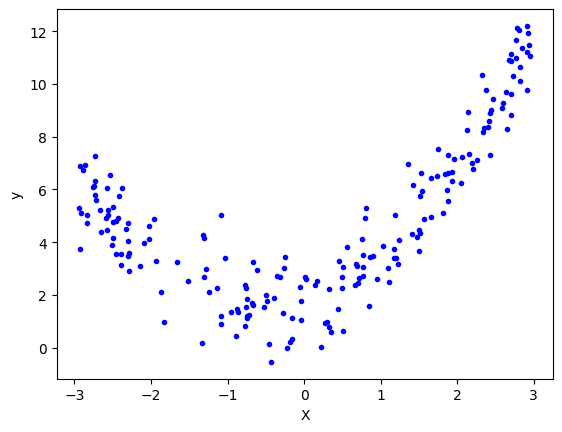

In [74]:
# Degree Is defined by sum of all degree in a term of equation

# generate Data having Polynomial Relation

# Using equation
# y = 0.8x^2 + 0.9x + 2

X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# Plot and verify

plt.plot(X, y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [75]:
# TTS
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

r2-Score -  0.026080002343350284


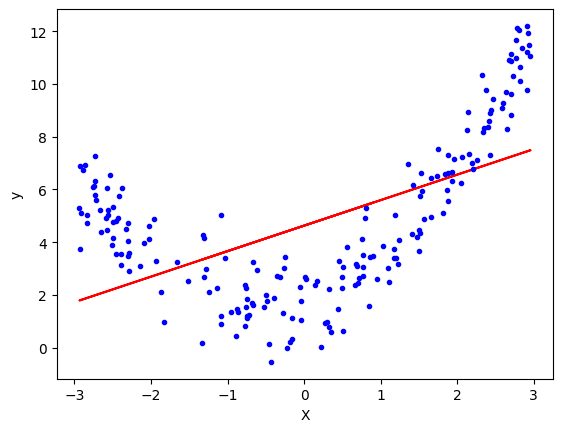

In [76]:
# Applying linear regression
lr = LinearRegression()

lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)
print('r2-Score - ',r2_score(y_test,y_pred))

# Check Position of our line
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

# Observation ->
# Generated Regression Line Doesn't Justify the Data

In [77]:
# Applying Polynomial Linear Regression

# Pre-processing of our Non - Linear Data
# degree 2
# Apply only on input column
poly = PolynomialFeatures(degree=2,include_bias=False) # If not included Bias then -> (x^0 -> 1) term will not be added 
# If Included -> 2 Intercept will fight to train. 

# One Way to avoid Redundent Intercept
# include_bias=False and set fit_intercept=True  -> Intercept will be calculated from Model
# include_bias=True and set fit_intercept=False  -> Intercept will be calculated from training data
# If both are False -> Regreesion Line will be forced to pass from Origin
# Both True -> Then Input B0 will be assigned to 0 and intrcept will be calculated from Model-> Output generated

# Degree 2  ->  1 column transform into 3 Column (Degree + 1) column

# Apply transformation on both train and test
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

print(X_train[0])
print(X_train_trans[0])

poly.powers_ # To check Powers

[0.89526181]
[0.89526181 0.80149371]


array([[1],
       [2]], dtype=int64)

In [78]:
lr = LinearRegression(fit_intercept=True)
lr.fit(X_train_trans,y_train)

y_pred = lr.predict(X_test_trans)

print('r2score - ', r2_score(y_test,y_pred))

print(lr.coef_)
print(lr.intercept_)

r2score -  0.8867432214862517
[[0.90964912 0.8052801 ]]
[1.92786144]


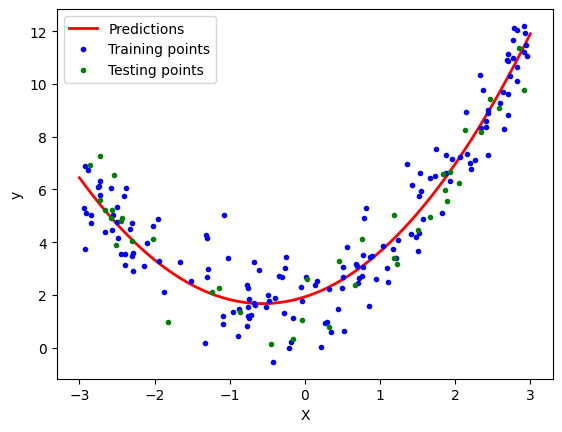

In [79]:
# Plot The Regreesion Line

X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# Observation -> True Essece of data is captured by degree 2

In [80]:
# Check with different Degree Value
# Underfit or overfit or optimal
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

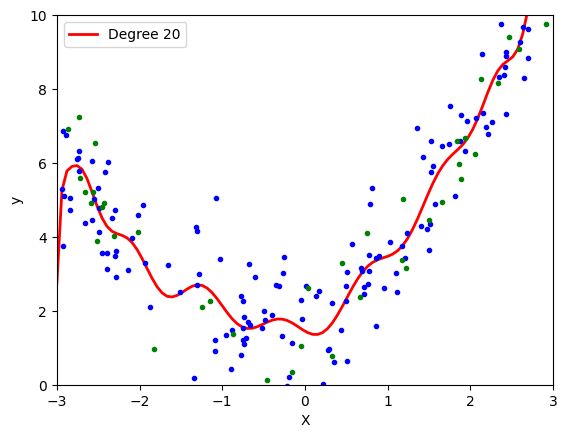

In [81]:
# Degree 1 -> UnderFit -> Straight Line
# Degree 10 -> OverFit -> curvy Line
polynomial_regression(20)

C:\Users\parij\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



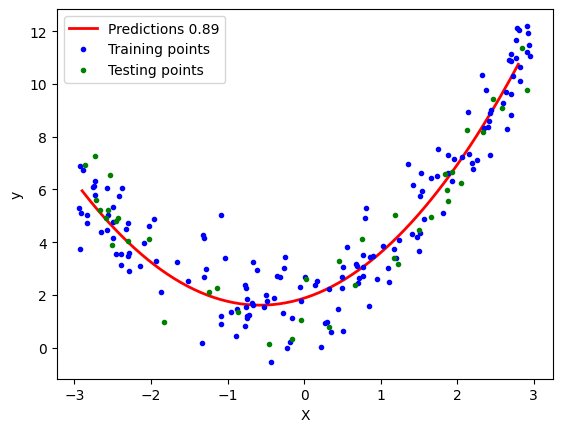

In [82]:
# Applying Gradient Descent

poly = PolynomialFeatures(degree=2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

sgd = SGDRegressor(max_iter=100)
sgd.fit(X_train_trans,y_train)

X_new=np.linspace(-2.9, 2.8, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = sgd.predict(X_new_poly)

y_pred = sgd.predict(X_test_trans)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test,y_pred),2)))
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [83]:
################### # 3D polynomial regression ################## 


x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [84]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)


fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [85]:
X_multi = np.array([x,y]).reshape(100,2)

poly = PolynomialFeatures(degree=2)
X_multi_trans = poly.fit_transform(X_multi)

print("Input",poly.n_features_in_)
print("Ouput",poly.n_output_features_)
# print("Powers\n",poly.powers_)

Input 2
Ouput 6


In [86]:
lr = LinearRegression()
lr.fit(X_multi,z)

X_test_multi = poly.transform(final)
z_final = lr.predict(X_multi).reshape(10,10)
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()

In [ ]:
# Parabolica

# 1. Generate synthetic data (z = x^2 + y^2 + noise)
np.random.seed(42)
n_points = 100
x = np.random.uniform(-5, 5, n_points)
y = np.random.uniform(-5, 5, n_points)
z = x**2 + y**2 + np.random.normal(0, 2, n_points)

# Prepare training data (X must be a 2D array of [x, y])
X_train = np.column_stack((x, y))

# 2. Transform features to Quadratic (Degree 2)
# This creates 6 features: [1, x, y, x^2, xy, y^2]
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)

# 3. Fit the Linear Regression model
lr = LinearRegression()
lr.fit(X_poly_train, z)

# 4. Create a dense grid for a smooth surface plot
grid_size = 30
x_range = np.linspace(x.min(), x.max(), grid_size)
y_range = np.linspace(y.min(), y.max(), grid_size)
x_grid, y_grid = np.meshgrid(x_range, y_range)

# Flatten grid to (900, 2) to match the expected input shape
grid_flat = np.column_stack((x_grid.ravel(), y_grid.ravel()))

# IMPORTANT: Transform the grid data using the same 'poly' object
# This ensures the model receives 6 features, not 2
grid_poly = poly.transform(grid_flat)
z_pred = lr.predict(grid_poly).reshape(grid_size, grid_size)

# 5. Visualize with Plotly
fig = go.Figure()

# Add original data points
fig.add_trace(go.Scatter3d(
    x=x, y=y, z=z, mode='markers',
    marker=dict(size=4, color=z, colorscale='Viridis', opacity=0.7),
    name='Actual Data'
))

# Add the fitted surface
fig.add_trace(go.Surface(
    x=x_range, y=y_range, z=z_pred,
    colorscale='Cividis', opacity=0.8,
    name='Fitted Paraboloid', showscale=False
))

fig.update_layout(
    title='3D Paraboloid: Polynomial Regression Fit',
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()
